# Categoricality says nothing about whether regions form types

A region's neurons are an elongated cloud in tuning-shape space. `amount` sets how bimodal
it is along its long axis -- how categorical the region is. `kind` ($\psi$) sets that axis's
orientation -- what the region is categorical *about*.

**Scenario 1 -- a continuum.** Regions vary continuously: `amount` sweeps from 0 to ~1 and
`kind` sweeps with it. The distribution of per-region categoricality is **spread out**, and
in region space the regions lie on a continuum with no types in it.

**Scenario 2 -- three kinds.** **No region is categorical at all** ($a$ = 0, so every
per-region $z$ sits at zero), but `kind` takes three discrete values, so region space
contains three clean clusters.

Read the first column and you learn nothing about the third.

### Why `amount` and `kind` are swept together in scenario 1

The generator holds a region's total spread fixed as `amount` changes, so the second moment
of its weights -- which is what a Procrustes comparison of regions sees -- depends on `kind`
and not on `amount`. Sweeping `amount` alone would spread the categoricality histogram while
leaving region space almost unchanged; sweeping `kind` alone would give the continuum but a
flat histogram. Scenario 1 needs both, and they are two visible consequences of one
underlying gradient.

### Two choices in scenario 1 that are not arbitrary

Its regions are **sampled** along the gradient rather than evenly spaced: an evenly spaced
lattice is itself non-Gaussian, and the region-space test would report that regularity as
structure.

And it sweeps only part of the $\psi$ range. Procrustes distance is a nonlinear function of
$\psi$, so a wide sweep puts the regions on a strongly **curved** arc -- and the
silhouette-versus-Gaussian test detects departure from a Gaussian, which curvature is. Over
the full range this simulation returns $p$ = 0.01 for a continuum containing no types
whatsoever. **That is a limitation of the test, not evidence of types**, and it is worth
knowing: a strongly curved continuum of regions can be reported as lumpy. Scenario 1 stays
in the near-straight regime so the intended contrast is the only thing on show.

### The region-space test

Regions are embedded by **classical MDS -- PCA of the Procrustes distances** (deterministic,
and its axes come out ordered by variance, unlike SMACOF). The statistic is the best
silhouette over $k$; the null is Gaussians matched to that embedding's mean and covariance.
A continuum is *not* lumpy in this sense -- a line of points and a Gaussian blob score
alike -- while genuine types are.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
import importlib
import region_space as R
# the module is edited alongside this notebook; reload so a re-run of this cell
# picks up the current file rather than whatever the kernel imported first
R = importlib.reload(R)

OUT = Path.cwd() / "results"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

# house style; the three-hue set passes the lightness, chroma, CVD (worst dE 22.1)
# and contrast checks, and keeps the two hues used by the other notebooks here
PANEL = 2.1
OBS, NULLC, GREY = "#B22222", "#1F6FB2", "0.75"
KIND_COLORS = ["#B22222", "#1F6FB2", "#E8A33D"]
N_DRAWS = 200
N_DRAWS_CAT = 25   # null draws per region for the categoricality z

print(f"{R.N_REGIONS} regions x {R.N_NEURONS} neurons")

60 regions x 100 neurons


## Running both scenarios

In [2]:
f = OUT / "region_2x3.npz"
if f.exists():
    res = np.load(f, allow_pickle=True)["res"].item()
else:
    res = {}
    for name in ("continuum", "kinds"):
        X, region, colour = R.scenario(name)
        E = R.pca_embed(R.procrustes_distances(X, region))
        res[name] = dict(
            colour=colour, emb=E,
            z=R.categoricality(X, region, np.random.default_rng(0), N_DRAWS_CAT),
            ct=R.continuum_or_types(E, N_DRAWS),
        )
    np.savez(f, res=np.array(res, dtype=object))

for name, r in res.items():
    print(f"\n=== {name} ===")
    print(f"  categoricality z : {r['z'].min():+.2f} to {r['z'].max():+.2f}"
          f"   (mean {r['z'].mean():+.2f} +/- {r['z'].std():.2f})")
    zz = r["z"]
    print(f"  regions with |z| > 1.96 : {int(np.sum(abs(zz) > 1.96))} of {len(zz)}"
          f"   |z| > {stats.norm.ppf(1 - 0.025 / len(zz)):.2f} (corrected):"
          f" {int(np.sum(abs(zz) > stats.norm.ppf(1 - 0.025 / len(zz))))}")
    print(f"  continuum or types: obs {r['ct']['obs']:.3f}  "
          f"null {r['ct']['null'].mean():.3f} +/- {r['ct']['null'].std():.3f}"
          f"   z = {r['ct']['z']:+.2f}   p = {r['ct']['p']:.3f}")


=== continuum ===
  categoricality z : -1.87 to +9.95   (mean +1.80 +/- 2.57)
  regions with |z| > 1.96 : 20 of 60   |z| > 3.34 (corrected): 14
  continuum or types: obs 0.309  null 0.287 +/- 0.025   z = +0.87   p = 0.199

=== kinds ===
  categoricality z : -1.77 to +3.08   (mean +0.27 +/- 0.99)
  regions with |z| > 1.96 : 2 of 60   |z| > 3.34 (corrected): 0
  continuum or types: obs 0.732  null 0.405 +/- 0.033   z = +9.92   p = 0.005


## The averaging alternative

The same regions, put in a common space a different way: average each region's neurons into
one tuning vector and PCA across regions -- the analysis of Posani et al.'s Fig. 2c. It is
essentially free to compute (no pairwise Procrustes), and it keeps only the first moment.

In [4]:
emb_mean = {}
for name in ("continuum", "kinds"):
    X, region, _ = R.scenario(name)
    emb_mean[name] = R.mean_embed(X, region)

rho_mean = stats.spearmanr(res["continuum"]["colour"], emb_mean["continuum"][:, 0])
rho_proc = stats.spearmanr(res["continuum"]["colour"], res["continuum"]["emb"][:, 0])
print(f"continuum: |rho(PC1, position)|   averaged {abs(rho_mean.statistic):.2f}"
      f"  (p = {rho_mean.pvalue:.2f})   vs Procrustes {abs(rho_proc.statistic):.2f}")

c, E = res["kinds"]["colour"], emb_mean["kinds"]
sep = np.mean([np.linalg.norm(E[c == i].mean(0) - E[c == j].mean(0))
               for i in range(R.N_KINDS) for j in range(i + 1, R.N_KINDS)])
within = np.mean([E[c == k].std(0).mean() for k in range(R.N_KINDS)])
print(f"kinds    : centroid separation {sep:.3f} vs within-kind spread {within:.3f}"
      "   -> the kinds overlap")

continuum: |rho(PC1, position)|   averaged 0.04  (p = 0.78)   vs Procrustes 0.96
kinds    : centroid separation 0.049 vs within-kind spread 0.126   -> the kinds overlap


## The figure

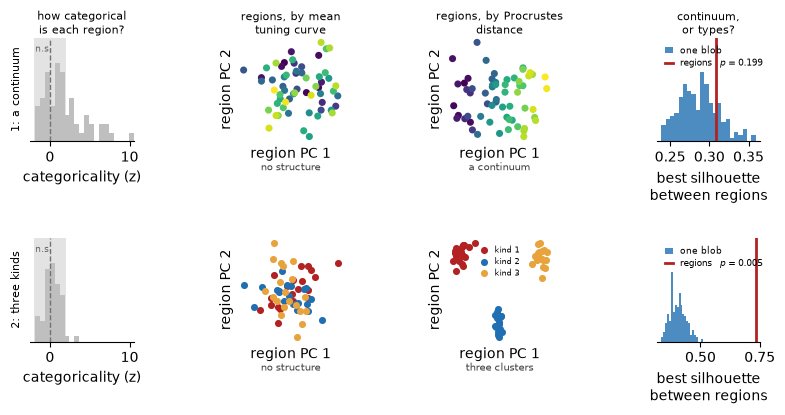

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(4 * PANEL, 2 * PANEL))
ROWS = [("continuum", res["continuum"], "1: a continuum"),
        ("kinds", res["kinds"], "2: three kinds")]

# shared bins so the two categoricality histograms are directly comparable
allz = np.concatenate([r["z"] for _, r, _ in ROWS])
ZBINS = np.linspace(np.floor(allz.min()) - .5, np.ceil(allz.max()) + .5, 22)


# identical colouring in both embedding columns: position along the continuum,
# or which kind
def plot_regions(ax, E, name, r, legend=False):
    if name == "continuum":
        ax.scatter(E[:, 0], E[:, 1], c=r["colour"], cmap="viridis", s=26,
                   linewidths=0)
    else:
        for k in range(R.N_KINDS):
            m = r["colour"] == k
            ax.scatter(E[m, 0], E[m, 1], c=KIND_COLORS[k], s=26, linewidths=0,
                       label=f"kind {k + 1}")
        if legend:
            ax.legend(frameon=False, fontsize=6, loc="best", handlelength=1.0,
                      scatterpoints=1, labelspacing=0.3)
    ax.set(xlabel="region PC 1", ylabel="region PC 2", xticks=[], yticks=[])
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True, bottom=True)


for row, (name, r, title) in enumerate(ROWS):
    # -- 1. the distribution of per-region categoricality ------------------
    ax = axes[row, 0]
    ax.hist(r["z"], bins=ZBINS, color=GREY)
    ax.axvline(0, color="0.45", lw=1, ls="--")
    # |z| < 1.96: not significantly categorical.  Drawn behind the bars.
    ax.set_xlim(ZBINS[0], ZBINS[-1])
    ylo, yhi = ax.get_ylim(); ax.set_ylim(0, yhi * 1.26)
    ax.axvspan(-1.96, 1.96, color="0.89", lw=0, zorder=0)
    ax.text(-1.85, yhi * 1.12, "n.s.", ha="left", va="center", fontsize=6.5,
            color="0.4")
    ax.set(xlabel="categoricality (z)", yticks=[])
    ax.set_ylabel(title, fontsize=8, labelpad=6)
    if row == 0:
        ax.set_title("how categorical\nis each region?", fontsize=8, pad=3)
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True)

    # -- 2. regions by their AVERAGED tuning (Fig-2c style) ----------------
    ax = axes[row, 1]
    plot_regions(ax, emb_mean[name], name, r)
    ax.text(0.5, -0.28, "no structure", fontsize=7.5, color="0.25",
            ha="center", transform=ax.transAxes)
    if row == 0:
        ax.set_title("regions, by mean\ntuning curve", fontsize=8, pad=3)

    # -- 3. regions by Procrustes distance ---------------------------------
    ax = axes[row, 2]
    plot_regions(ax, r["emb"], name, r, legend=(row == 1))
    ax.text(0.5, -0.28, "a continuum" if name == "continuum" else "three clusters",
            fontsize=7.5, color="0.25", ha="center", transform=ax.transAxes)
    if row == 0:
        ax.set_title("regions, by Procrustes\ndistance", fontsize=8, pad=3)

    # -- 4. continuum, or types? -------------------------------------------
    ax = axes[row, 3]
    ct = r["ct"]
    ax.hist(ct["null"], bins=22, color=NULLC, alpha=0.8, label="one blob")
    # p in the legend label, so it cannot collide with the legend box
    ax.axvline(ct["obs"], color=OBS, lw=2,
               label=f"regions   $p$ = {ct['p']:.3f}")
    ax.set(xlabel="best silhouette\nbetween regions", yticks=[])
    ylo, yhi = ax.get_ylim(); ax.set_ylim(ylo, yhi * 1.42)
    ax.legend(frameon=False, fontsize=6.2, loc="upper left", handlelength=1.0,
              labelspacing=0.3)
    if row == 0:
        ax.set_title("continuum,\nor types?", fontsize=8, pad=3)
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True)

fig.tight_layout(w_pad=1.6, h_pad=2.8)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_space.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## Reading the figure

**Row 1 -- a continuum.** Categoricality is spread across the range: some regions are
strongly categorical, others not at all. In region space the regions form **one continuous
cloud with an ordering through it** -- PC1 recovers position along the continuum -- and the
best silhouette between regions is indistinguishable from a single blob. There are no region
types, however categorical the individual regions are.

**Row 2 -- three kinds.** Every region's categoricality sits at zero: a couple of the 60
regions drift past $|z|$ = 1.96, which is what testing 60 regions at $\alpha$ = 0.05 is
*expected* to produce by chance, and against the threshold corrected for 60 tests
($|z|$ = 3.34) not one region is significantly categorical. Yet the same regions fall into
three clean clusters, far above the blob null.

**The middle column** is a control on the method rather than on the data: averaging each
region's neurons into one tuning curve -- the analysis of Posani et al.'s Fig. 2c -- loses
both effects. The ordering of row 1 and the three clusters of row 2 appear only when regions
are compared as whole populations.

## What to take from it

The left column and the right column answer different questions and neither constrains the
other. A field of strongly categorical regions can form a seamless continuum; a field of
entirely non-categorical regions can be sharply divided into types.

**A caveat on the region-space test itself.** It compares the best silhouette against a
Gaussian, so it detects departure from a Gaussian -- not clustering specifically. A strongly
curved continuum is such a departure: run scenario 1 across the full $\psi$ range and it
returns $p$ = 0.01 with no types present at all. Report that as evidence for region types and
you would be wrong. Curvature and lumpiness need to be told apart, by inspecting the
embedding rather than trusting the $p$-value alone.
